# Power Flow Equations and more 

In [1]:
import pandapower as pp
import sys 
import os 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from utils.ppnet_utils import add_branch_parameters

# create empty net
net = pp.create_empty_network()

# create buses
b1 = pp.create_bus(net, vn_kv=20., name="Bus 1")
b2 = pp.create_bus(net, vn_kv=20., name="Bus 2")
b3 = pp.create_bus(net, vn_kv=20., name="Bus 3")
b4 = pp.create_bus(net, vn_kv=0.4, name="Bus 4")

# create bus elements
pp.create_ext_grid(net, bus=b1, vm_pu=1.02, name="Grid Connection")
pp.create_load(net, bus=b2, p_mw=0.1, q_mvar=0.05, name="Load 1")
pp.create_load(net, bus=b3, p_mw=0.9, q_mvar=0., name="Load 2")
pp.create_sgen(net, bus=b4, p_mw=0.22, name="Gen 1")

# create branch elements
pp.create_transformer(net, hv_bus=b3, lv_bus=b4, std_type="0.4 MVA 20/0.4 kV", name="Trafo")
pp.create_line(net, from_bus=b1, to_bus=b2, length_km=1.0, name="Line",std_type="NA2XS2Y 1x150 RM/25 12/20 kV")
pp.create_line(net, from_bus=b2, to_bus=b3, length_km=1.0, name="Line",std_type='NA2XS2Y 1x120 RM/25 12/20 kV')
pp.create_line(net, from_bus=b1, to_bus=b3, length_km=1.0, name="Line",std_type="NA2XS2Y 1x70 RM/25 12/20 kV")

np.int64(2)

### Transformer parameters calculation 
NOTE: 
1. Short-circuit test (SCT) is carried out at the HV side. 
2. Open-circuit test (OCT) is carried out at the LV side. 
3. Parameters for calculating the series impedance using SCT: `vk_percent`, `vkr_percent` with base voltages at HV side. 
4. Parameters for calculating the shunt impedance using OCT: `i0_percent`, `pfe_kw` representing the no load current and iron losses respectively. 

Finding series parameters: $R_{s}$ and $X_{s}$ using SCT: 
  
1. Base impedance: $Z_{BASE} = \frac{V_{HV}^2}{S_{n,trafo}} = \frac{(20kV)^2}{0.4 MVA} = 400 \Omega$.
2. $V_{k} =$ `vk_percent`/100 * $V_{HV} = \frac{6}{100} * 20 * 10^{3} = 1.2kV$ and similarly, $V_{kr} = 0.285kV$.
3. Using the transformer ratio, $I_{HV} = 20A$. 
4. Series impedance: $Z_{s} = \frac{V_{k}}{I_{HV}Z_{BASE}} = \frac{1.2kV}{20*400} = 0.150pu$.
5. Series resistance: $R_{s} = \frac{V_{kr}}{I_{HV}Z_{BASE}} = \frac{0.285kV}{20*400} = 0.03525pu$. 
6. From above results, $X_{s} = \sqrt{Z_s^2 - R_{s}^2} = 0.1457pu$.

Finding shunt parameters: $R_{sh}$ and $X_{sh}$ using OCT: 

1. Base current $I_{LV} = 1000A$, so, no load current $I_0 =$ `i0_percent`$/100 * I_{HV} = \frac{0.3375}{100} * 1000 = 3.375A$. 
2. Base impedance $Z_{BASE,LV} = \frac{V_{LV}^2}{S_{n,trafo}} = \frac{(0.4kV)^2}{0.4MVA} = 0.4\Omega$. 
3. Rated voltage $V_{LV} = 0.4kV$, since OCT. 
4. Power factor angle: $\cos{\phi_{0}} =$ `pfe_kw` $/(V_{LV}I_0) = 1.0$. 
5. So, $X_{0} = \frac{I_{0} \sin{\phi_0}V_1}{I_0^2} = 0.0$.
6. So, $R_{0} = \frac{I_{0} \cos{\phi_0}V_1}{I_0^2} = 118.518$.
7. $G_0 = \frac{1}{R_{0}} * Z_{BASE,LV} = \frac{0.4}{118.518} = 0.003375pu$. 
8. No $B_0$ since power factor angle $= 1.0$. 


In [ ]:
#

0.023876035623045147

In [ ]:
z_12 = 0.00135 + 1j*0.003093
y_s_12 = 1 / z_12 
y_s_12

(1.5835000846894736-6.476237539347546j)

0.035625

In [26]:
net.trafo 

,name,std_type,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,...,tap_dependency_table,parallel,df,in_service,shift_rad,tap_nom,r_pu,x_pu,g_pu,b_pu
0,Trafo,0.4 MVA 20/0.4 kV,2,3,0.4,20.0,0.4,6.0,1.425,1.35,...,False,1,1.0,True,0.0,1.0,0.035618,0.145712,0.00135,-6.641188e-08


No or insufficient geodata available --> Creating artificial coordinates. This may take some time


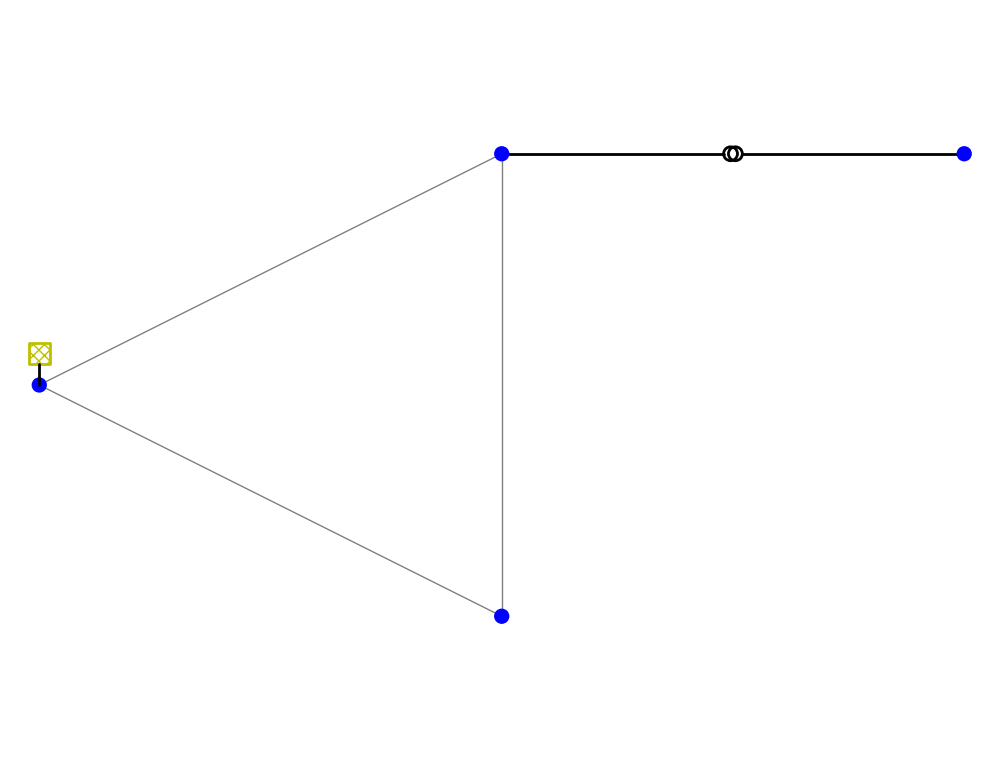

<Axes: >

In [ ]:
pp.plotting.simple_plot(net)

In [11]:
net.trafo.shift_degree = 0.0
pp.runpp(net)

In [12]:
net.res_bus 

,vm_pu,va_degree,p_mw,q_mvar
0,1.020000,0.000000,-0.783331,0.030797
1,1.019787,-0.005275,0.100000,0.050000
2,1.019596,-0.009476,0.900000,0.000000
3,1.026728,1.739630,-0.220000,0.000000


In [5]:
net.trafo.i0_percent

0    0.3375
Name: i0_percent, dtype: float64

In [6]:
net = add_branch_parameters(net)
net.line 

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,...,parallel,type,in_service,geo,r_pu,x_pu,b_pu,g_pu,tap_nom,shift_rad
0,Line,NA2XS2Y 1x150 RM/25 12/20 kV,0,1,1.0,0.206,0.116,250.0,0.0,0.319,...,1,cs,True,NaN,0.000515,0.000290,0.031416,0.0,0,0
1,Line,NA2XS2Y 1x120 RM/25 12/20 kV,1,2,1.0,0.253,0.119,230.0,0.0,0.283,...,1,cs,True,NaN,0.000633,0.000297,0.028903,0.0,0,0
2,Line,NA2XS2Y 1x70 RM/25 12/20 kV,0,2,1.0,0.443,0.132,190.0,0.0,0.220,...,1,cs,True,NaN,0.001107,0.000330,0.023876,0.0,0,0


In [7]:
net.trafo

,name,std_type,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,...,tap_dependency_table,parallel,df,in_service,shift_rad,tap_nom,r_pu,x_pu,g_pu,b_pu
0,Trafo,0.4 MVA 20/0.4 kV,2,3,0.4,20.0,0.4,6.0,1.425,1.35,...,False,1,1.0,True,0.0,1.0,0.035618,0.145712,0.00135,-6.641188e-08


No column named trafo.tap_pos, using tap_ratios...


,name,std_type,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,...,r_pu,x_pu,g_pu,b_pu,r_per_unit,x_per_unit,g_per_unit,b_per_unit,tap_ratio,n_tap
0,Trafo,0.4 MVA 20/0.4 kV,2,3,0.4,20.0,0.4,6.0,1.425,1.35,...,0.035618,0.145712,0.00135,-6.641188e-08,0.089063,0.36427,0.003375,0.0,1.0,1.0
